In [1]:
import os, sys, warnings

import earthaccess
from osgeo import gdal

import pandas as pd
import numpy as np
import xarray as xr
import math
import glob

import rasterio as rio

import netCDF4 as nc
from datetime import datetime, timedelta, timezone

from scipy import ndimage as ndi
from scipy.ndimage import binary_fill_holes, center_of_mass, distance_transform_edt
from scipy.interpolate import PchipInterpolator  # monotone, shape-preserving

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy import linalg
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation, rotate, shift
from skimage.transform import hough_line, hough_line_peaks
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
    inpaint_biharmonic
)

# This will ignore some warnings caused by holoviews
warnings.simplefilter('ignore') 

sys.path.append('../../EMIT-Data-Resources/python/modules/')
from emit_tools import emit_xarray, ortho_xr

sys.path.append('../')
from config import *
from test_runs import *
from REFERENCE_PLANTS import REFERENCE_PLANTS

sys.path.append('../../datasets/')
import get_geosfp
import get_campd
import importlib

# Reload the module
importlib.reload(get_campd)
importlib.reload(get_geosfp)

get_emission_rate = get_campd.get_emission_rate
get_emissions = get_campd.get_emissions

get_geosfp_wind = get_geosfp.get_geosfp_wind
get_geosfp_tph = get_geosfp.get_geosfp_tph


wav_min = 418
wav_max = 492
bin_size = 4
polydeg = 3

PREFIXES = {'OBS': 'EMIT_L1B_OBS_001_',
 'L1B': 'EMIT_L1B_RAD_001_',
 'MASK': 'EMIT_L2A_MASK_001_',
 'L2A': 'EMIT_L2A_RFL_001_'}

help(emit_xarray)

Help on function emit_xarray in module emit_tools:

emit_xarray(filepath, ortho=False, qmask=None, unpacked_bmask=None)
    This function utilizes other functions in this module to streamline opening an EMIT dataset as an xarray.Dataset.
    
    Parameters:
    filepath: a filepath to an EMIT netCDF file
    ortho: True or False, whether to orthorectify the dataset or leave in crosstrack/downtrack coordinates.
    qmask: a numpy array output from the quality_mask function used to mask pixels based on quality flags selected in that function. Any non-orthorectified array with the proper crosstrack and downtrack dimensions can also be used.
    unpacked_bmask: a numpy array from  the band_mask function that can be used to mask band-specific pixels that have been interpolated.
    
    Returns:
    out_xr: an xarray.Dataset constructed based on the parameters provided.



In [2]:
csv_savefn = f"{CONFIG['data_folder']}/metadata.csv"
data = pd.read_csv(csv_savefn)
data

,LOC_NAME,GRANULE,LON,LAT,GOOD_DATA,PLUME,CAMPD_RATE,HRRR_AGL_DIR,HRRR_AGL_SPD,HRRR_10M_DIR,HRRR_10M_SPD,GEOSFP_50M_DIR,GEOSFP_50M_SPD
0,Belews_Creek,20240824T151209_2423710_011,-80.0603,36.2811,True,True,0.560577,52.464461,0.528483,81.628728,0.484439,45.794820,1.257885
1,Belews_Creek,20240422T161538_2411311_024,-80.0603,36.2811,True,True,0.088643,357.751698,4.452453,358.256223,2.760645,7.441396,2.480177
2,Belews_Creek,20250803T153928_2521510_028,-80.0603,36.2811,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Belews_Creek,20250813T185258_2522512_035,-80.0603,36.2811,True,False,0.110787,247.873071,4.946592,240.060158,1.849816,239.351694,2.786438
4,Belews_Creek,20250809T203119_2522113_041,-80.0603,36.2811,True,False,0.101813,62.368539,3.326055,43.035219,2.194157,61.823987,1.019770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,Fort_Martin_Power_Station,20250806T145037_2521810_013,-79.9275,39.7107,True,False,0.114626,108.922932,5.610980,100.103079,2.663596,128.968177,1.903194
285,Fort_Martin_Power_Station,20250810T194210_2522213_031,-79.9275,39.7107,True,True,0.271314,153.450156,1.140011,158.274626,0.472135,230.940395,1.036547
286,Fort_Martin_Power_Station,20240725T200038_2420713_025,-79.9275,39.7107,True,False,0.151021,301.567015,4.871232,298.133967,3.600040,296.708788,1.753613
287,Fort_Martin_Power_Station,20240625T143059_2417710_011,-79.9275,39.7107,True,False,0.077388,200.492303,4.616291,199.732119,3.200004,212.949933,3.295396


In [ ]:
SKIPPED = ['20250816T193520_2522813_017']


In [3]:
loc_name = 'Intermountain'
data_for_loc = data[data['LOC_NAME'] == loc_name]
work_loc_data = data_for_loc[data_for_loc['PLUME'] == True]
granules = work_loc_data['GRANULE'].values
for i, g in enumerate(granules):
    print(f'{i}\t{g}')

0	20231005T183601_2327812_013
1	20240804T181803_2421712_014
2	20250609T222850_2516014_017
3	20250816T193520_2522813_017
4	20241005T174121_2427912_013
5	20240212T214534_2404314_009
6	20241001T191716_2427513_010
7	20240216T200912_2404713_005
8	20230927T214729_2327014_012
9	20230202T193710_2303313_007
10	20230620T193346_2317113_008
11	20250820T175830_2523212_017
12	20250424T164449_2511411_003
13	20250420T182035_2511012_017


In [154]:
granule_name = granules[3]
granule_data = data[data['GRANULE'] == granule_name]
fp_mask = f"{CONFIG['data_folder']}/{loc_name}/{PREFIXES['MASK']}{granule_name}.nc"

print(f"LOC_NAME: {loc_name}\nGRANULE: {granule_name}")
# print(f"{fp_mask=}")

loc_type = 'plant'

if loc_type == 'plant':
    loc_data = REFERENCE_PLANTS[loc_name]
else:
    loc_data = LOCS[loc_name]

retrieval_fpath = f"{CONFIG['results_folder']}/{CONFIG['retr_subdir']}/{loc_name}/dSCD_{PREFIXES['L1B']}{granule_name}.npy"
radiance_fpath = f"{CONFIG['data_folder']}/{loc_name}/{PREFIXES['L1B']}{granule_name}.nc"

obs_time = datetime.strptime(granule_name.split('_')[0], "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)

# campd_e_rate = get_emission_rate(loc_data, obs_time, timedelta(hours=4))
campd_e_rate = granule_data["CAMPD_RATE"].values[0]
print(f"campd emission rate for 4 hours prior: {campd_e_rate:0.2f} kg/s")

mean_windspeed = granule_data[["GEOSFP_50M_SPD", "HRRR_10M_SPD", "HRRR_AGL_SPD"]].iloc[0].mean()
print(f"mean wind speed {mean_windspeed:0.2f} m/s")
# wind_info = get_geosfp_wind(loc_data['LAT'], loc_data['LON'], obs_time, cache=f'{CONFIG["geosfp"]}/')
# wind_info

LOC_NAME: Intermountain
GRANULE: 20250816T193520_2522813_017
campd emission rate for 4 hours prior: 0.13 kg/s
mean wind speed 7.21 m/s


Completed orthorectification


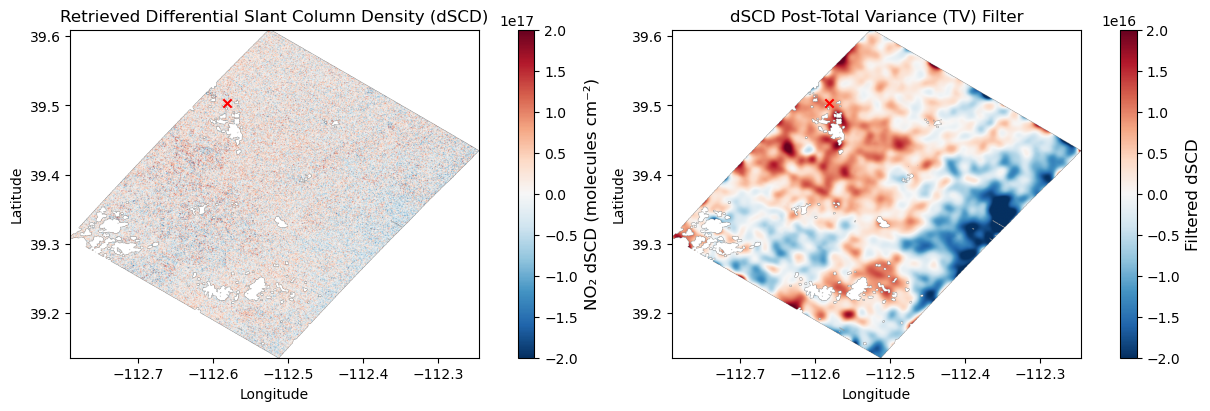

In [155]:
ds_no_orth = emit_xarray(radiance_fpath, ortho=False)
retrieval = np.load(retrieval_fpath)

dSCD = np.load(retrieval_fpath)
ds_no_orth = emit_xarray(radiance_fpath)

wl_val = float(ds_no_orth["wavelengths"].isel(wavelengths=0))  # or a specific value
dscd_da = xr.DataArray(
    dSCD.astype('float32')[..., None],  # -> (downtrack, crosstrack, 1)
    dims=("downtrack", "crosstrack", "wavelengths"),
    coords={
        "downtrack": ds_no_orth["downtrack"],
        "crosstrack": ds_no_orth["crosstrack"],
        "wavelengths": [wl_val],
    },
    name="dSCD",
    attrs={
        "long_name": "Differential Slant Column Density (single band)",
        "units": "molec cm^-2",
    },
)
ds_no_orth = ds_no_orth.assign(dSCD=dscd_da)
ds = ortho_xr(ds_no_orth)

(dy, dx) = ds.rio.resolution() # in deg
pix_pitch_m = 111000 * abs(dy)

del ds_no_orth

bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values))

# axs[i].imshow(ds['radiance'][:,:,0], cmap='gray', extent=bounds)
rad1500 = ds['radiance'].sel(wavelengths=1500, method='nearest').values
dSCD_nan = np.where(rad1500 <= -8000, np.nan, ds['dSCD'].values[:,:,0])*1e19

valid_lat = ds['latitude'].values[np.where(~np.isnan(dSCD_nan))[0]]
valid_lon = ds['longitude'].values[np.where(~np.isnan(dSCD_nan))[1]]

latmin_bnd, latmax_bnd = valid_lat.min(), valid_lat.max()
lonmin_bnd, lonmax_bnd = valid_lon.min(), valid_lon.max()

print(f"Completed orthorectification")

mask = np.isfinite(dSCD_nan)

_, idx = distance_transform_edt(~mask, return_indices=True)
filled = dSCD_nan[tuple(idx)]/1e19   # copies nearest valid value into each NaN pixel

tv = denoise_tv_chambolle(filled, weight=0.2)
tv[~mask] = np.nan


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4), layout='constrained')

im = ax[0].imshow(dSCD_nan, cmap='RdBu_r', origin='upper', 
              aspect='auto', vmin=-2e17, vmax=2e17, extent=bounds)
cb = plt.colorbar(im, ax=ax[0])
cb.set_label("NO₂ dSCD (molecules cm⁻²)", fontsize=12)
ax[0].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')
ax[0].set_title('Retrieved Differential Slant Column Density (dSCD)')

im = ax[1].imshow(tv*1e19, cmap='RdBu_r', origin='upper', 
              aspect='auto', vmin=-2e16, vmax=2e16, extent=bounds)
cb = plt.colorbar(im, ax=ax[1])
cb.set_label("Filtered dSCD", fontsize=12)
ax[1].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')
ax[1].set_title('dSCD Post-Total Variance (TV) Filter')

for a in ax:
    a.set_xlim(lonmin_bnd, lonmax_bnd)
    a.set_ylim(latmin_bnd, latmax_bnd)

    a.set_ylabel('Latitude')
    a.set_xlabel('Longitude')

plt.show()

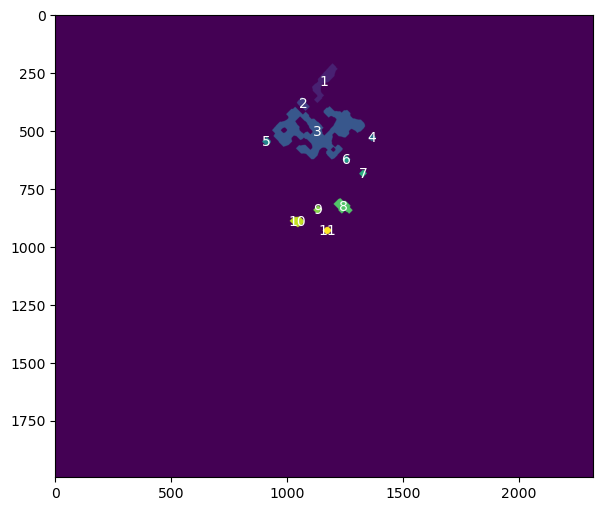

In [158]:
def get_plume_mask(img, pct=97, open_iters=4, close_iters=4, min_size=500):
    """
    img: 2D array (NaNs allowed)
    pct: percentile used for threshold (e.g., 95–99)
    open_iters/close_iters: morphology to denoise/bridge small gaps
    min_size: drop tiny specks before picking the two largest blobs
    """
    # 1) Threshold on high values (tune pct as needed)
    valid = np.isfinite(img)
    thr = np.nanpercentile(img, pct)
    bw = valid & (img >= thr)

    # 2) Morphology to clean the mask
    # Opening removes salt noise; closing bridges small gaps.
    bw = ndi.binary_opening(bw, iterations=open_iters)
    bw = ndi.binary_closing(bw, iterations=close_iters)

    # Remove very small objects
    lbl, n = ndi.label(bw)
    if n == 0:
        return np.zeros_like(bw, bool), np.zeros_like(bw, bool)

    sizes = ndi.sum(np.ones_like(bw), labels=lbl, index=np.arange(1, n+1))
    keep = {i+1 for i, s in enumerate(sizes) if s >= min_size}
    bw = np.isin(lbl, list(keep))

    # Re-label after size filter, fill holes
    lbl, n = ndi.label(bw)
    if n == 0:
        return np.zeros_like(bw, bool), np.zeros_like(bw, bool)
    lbl = ndi.binary_fill_holes(lbl>0).astype(int) * lbl

    return lbl

lbls = get_plume_mask(tv, pct=80, open_iters=14, close_iters=8)

plt.figure(figsize=(10,6))
plt.imshow(lbls, cmap='viridis')# extent=bounds)
# plt.scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')

# unique labels, excluding background (0)
regions = np.unique(lbls)
regions = regions[regions != 0]

for r in regions:
    cy, cx = center_of_mass(lbls == r)
    plt.text(cx, cy, str(r), color='white', fontsize=10, ha='center', va='center')

plt.show()

31481


Text(0, 0.5, 'Latitude')

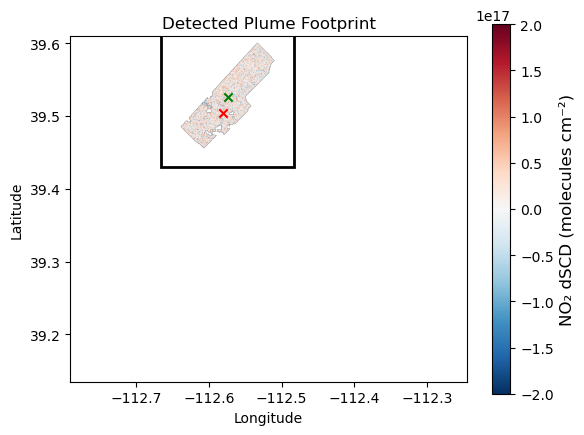

In [159]:
PLUME_ID = [1,2]

plume_mask = np.isin(lbls, PLUME_ID)

plume_mask_filled = binary_fill_holes(plume_mask)
plume_mask_filled = binary_dilation(plume_mask_filled, iterations=120)
plume_mask_filled = binary_fill_holes(plume_mask_filled)
plume_mask_filled = binary_erosion(plume_mask_filled, iterations=80)
plume_mask_filled = binary_fill_holes(plume_mask_filled)

plume_size_init = np.sum([1 if k else 0 for k in plume_mask_filled.flatten()])
print(plume_size_init)

## Get plume dSCD
dSCD_plume_masked = np.where(plume_mask_filled, dSCD_nan, np.nan)

## Get plume center
rows, cols = np.indices(dSCD_plume_masked.shape)
m = np.isfinite(dSCD_plume_masked)
xw = np.nansum(cols[m] * np.clip(dSCD_plume_masked[m], 0, None) ) / np.nansum(np.clip(dSCD_plume_masked[m], 0, None))
yw = np.nansum(rows[m] * np.clip(dSCD_plume_masked[m], 0, None) ) / np.nansum(np.clip(dSCD_plume_masked[m], 0, None))

## Boundary for full image, get a grid for lat/lon
bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values))

lon_grid = np.linspace(np.min(ds['longitude'].values), np.max(ds['longitude'].values), num=dSCD_plume_masked.shape[1])
lat_grid = np.linspace(np.min(ds['latitude'].values), np.max(ds['latitude'].values), num=dSCD_plume_masked.shape[0])

## Get bounding box
y_mask, x_mask = np.where(~np.isnan(dSCD_plume_masked))
pad = 50
bbox = (max(0, x_mask.min()-pad), min(len(lon_grid)-1, x_mask.max()+pad),
        max(-len(lat_grid)+1, -y_mask.min()+pad), min(0, -y_mask.max()-pad))

bounding_box = (lon_grid[bbox[0]], lon_grid[bbox[1]], 
                lat_grid[bbox[2]], lat_grid[bbox[3]])


im = plt.imshow(dSCD_plume_masked, cmap='RdBu_r', extent=bounds, vmin=-2e17, vmax=2e17)
cb = plt.colorbar(im)
cb.set_label("NO₂ dSCD (molecules cm⁻²)", fontsize=12)
plt.scatter([lon_grid[int(xw)]], [lat_grid[-int(yw)]], marker='x', c='g')
plt.scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')

lon_min, lon_max, lat_min, lat_max = bounding_box
rect = patches.Rectangle((lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
                 linewidth=2, edgecolor='k', facecolor='none')
plt.gca().add_patch(rect)

plt.xlim(lonmin_bnd, lonmax_bnd)
plt.ylim(latmin_bnd, latmax_bnd)

plt.title("Detected Plume Footprint")
plt.xlabel('Longitude')
plt.ylabel('Latitude')

23595


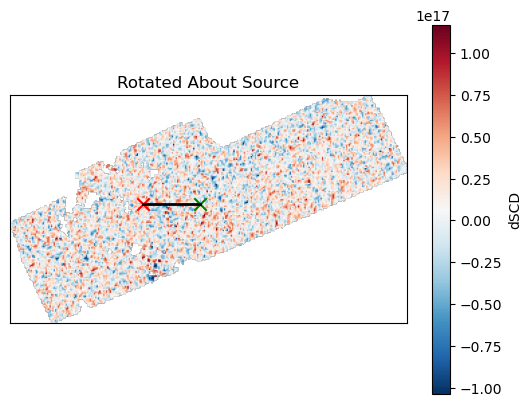

In [160]:
# --- helpers ---
ni = lambda v,a: int(np.argmin(np.abs(a - v)))

# pixel indices (global)
Rr,Rc = len(lat_grid)-ni(loc_data['LAT'], lat_grid), ni(loc_data['LON'], lon_grid) 
Gr, Gc = int(yw), int(xw)

# tight crop (with pad)
ym,xm = np.where(np.isfinite(dSCD_plume_masked)); pad=50
r0,r1 = max(0, ym.min()-pad), min(dSCD_plume_masked.shape[0], ym.max()+pad+1)
c0,c1 = max(0, xm.min()-pad), min(dSCD_plume_masked.shape[1], xm.max()+pad+1)
img   = dSCD_plume_masked[r0:r1, c0:c1].copy()
Rr,Rc,Gr,Gc = Rr-r0, Rc-c0, Gr-r0, Gc-c0

# plt.imshow(img); plt.scatter([Rc], [Rr]); plt.scatter([Gc], [Gr]); plt.show()

# angle to make red→green horizontal to the RIGHT
dx, dy = (Gc-Rc), (Gr-Rr)
angle  = -np.degrees(np.arctan2(-dy, dx))   # rotate by this

# pad so nothing clips; shift so RED at center
H,W = img.shape; P = max(H,W)
img  = np.pad(img, P, constant_values=np.nan)
Rr,Rc,Gr,Gc = Rr+P, Rc+P, Gr+P, Gc+P
H,W = img.shape; cy, cx = H/2, W/2

valid = np.isfinite(img).astype(float)

# plt.imshow(valid); plt.scatter([Rc], [Rr]); plt.scatter([Gc], [Gr]); plt.show()

vals  = np.nan_to_num(img, nan=0.0)
shift_vec = (cy - Rr, cx - Rc)
vals  = shift(vals,  shift_vec, order=1, mode='constant', cval=0.0, prefilter=False)
valid = shift(valid, shift_vec, order=1, mode='constant', cval=0.0, prefilter=False)

# plt.imshow(valid)
# print(vals.shape)
# print(valid.shape)

# normalized rotation (preserve plume; expand canvas)
num = rotate(vals*valid, angle, reshape=True, order=1, mode='constant', cval=0.0, prefilter=False)
den = rotate(valid,      angle, reshape=True, order=1, mode='constant', cval=0.0, prefilter=False)
with np.errstate(divide='ignore', invalid='ignore'):
    img_rot = num/den
img_rot[den < 1e-6] = np.nan

# plt.imshow(img_rot);
# print(np.isnan(img_rot))
plume_size_rot = np.sum([0 if k else 1 for k in np.isnan(img_rot.flatten())])
print(plume_size_rot)

# rotate GREEN relative to RED using the CORRECT image-space mapping
theta = np.deg2rad(-angle); c,s = np.cos(theta), np.sin(theta)
x_r =  c*dx - s*dy
y_r =  s*dx + c*dy

# red is now at canvas center; green goes to the right at same y
Rx, Ry = img_rot.shape[1]/2, img_rot.shape[0]/2
Gx, Gy = Rx + x_r, Ry + y_r   # Gy == Ry (horizontal), x_r > 0 (to the right)

# plot in pixel space (no lon/lat ticks)
plt.figure()
vmin, vmax = np.nanpercentile(img, [1,99]) if np.isfinite(img).any() else (None,None)
plt.imshow(img_rot, origin='upper', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(label='dSCD')
plt.plot([Rx, Gx], [Ry, Gy], 'k-', lw=2)        # horizontal by construction
plt.scatter([Rx],[Ry], c='r', marker='x', s=80) # source (center)
plt.scatter([Gx],[Gy], c='g', marker='x', s=80) # plume center (to the right)
ax=plt.gca()
# ax.set_xticks([]); ax.set_yticks([]); 
ax.set_aspect('equal','box')
plt.title('Rotated About Source')


vy = np.where(~np.isnan(img_rot))[0]
vx = np.where(~np.isnan(img_rot))[1]

plt.xlim(vx.min(), vx.max())
plt.ylim(vy.min(), vy.max())

plt.xticks([])
plt.yticks([])

plt.show()

Approx pixel pitch: 52.11 m/pix
Plume-integrated NO₂ mass (kg·m⁻¹): 2.860e+00
Mean retrieved emission rate: 0.12 kg/s
Mean CAMPD emission rate: 0.13 kg/s


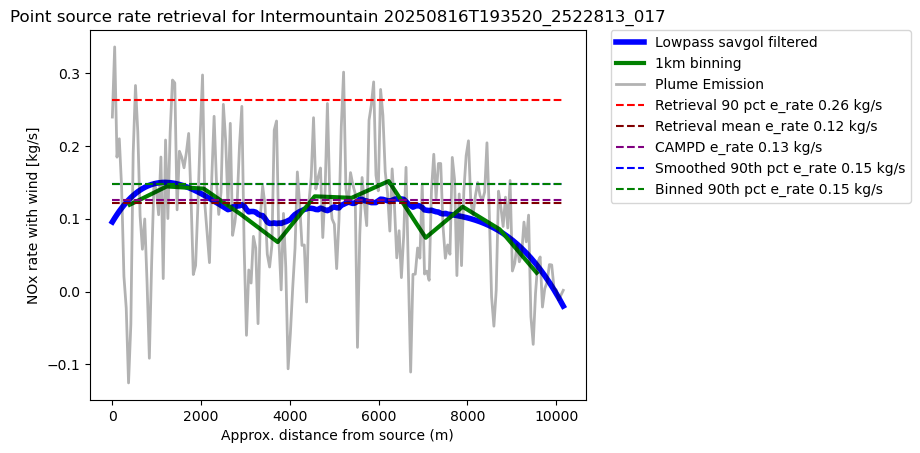

In [161]:
pix_pitch = pix_pitch_m * np.sqrt(plume_size_rot/plume_size_init)
print(f"Approx pixel pitch: {pix_pitch:0.4} m/pix")

amf_eff = 2

AMF = amf_eff
integrated_flux = np.nansum(img_rot, axis=0)*pix_pitch/AMF

# integrated_flux already defined
molec_to_kg_NO2 = 46 / (6.022e23 * 1000)
NOx_NO2_ratio = 1.4 # common value
NO2_kg_m2 = integrated_flux * molec_to_kg_NO2 * NOx_NO2_ratio * 1e4 # cm² → m²

# define indices
start_idx = int(Rx)  # source (red cross)
end_idx = np.where(NO2_kg_m2 > 0)[0][-1]

# threshold = 0.05 * np.nanmax(NO2_kg_m2)  # e.g. 5% of peak as cutoff
# end_idx = start_idx + np.argmax(NO2_kg_m2[start_idx:] < threshold)

# restrict the array
x = np.arange(len(NO2_kg_m2))
NO2_restricted = NO2_kg_m2[start_idx:end_idx]

# compute total plume mass (integrated along track)
plume_mass = np.nansum(NO2_restricted)
print(f"Plume-integrated NO₂ mass (kg·m⁻¹): {plume_mass:.3e}")

plume_extent = x[start_idx:end_idx]*pix_pitch-start_idx*pix_pitch
plume_emission = NO2_kg_m2[start_idx:end_idx]

Q = plume_emission*mean_windspeed
e_rate = np.mean(Q[Q > 0])

print(f"Mean retrieved emission rate: {e_rate:0.2f} kg/s")
print(f"Mean CAMPD emission rate: {campd_e_rate:0.2f} kg/s")



smoothed = savgol_filter(Q, window_length=101, polyorder=3) #smooth over 60*101 ~= 6km

# Smooth then base on top 10% of emission data
smoothed_maxrate = np.mean(smoothed[smoothed >= np.percentile(smoothed, 90)])

binned = np.array([np.mean(Q[x:x+16]) for x in range(0,len(Q)-16,16)])
bin_extent = [np.mean(plume_extent[x:x+16]) for x in range(0,len(Q)-16,16)]
bin_maxrate = np.mean(binned[binned >= np.percentile(binned, 90)])
plt.plot(bin_extent, binned)

nofilt_maxrate = np.mean(Q[Q >= np.percentile(Q, 90)])


plt.plot(plume_extent, smoothed,'blue', lw=4, label='Lowpass savgol filtered')
plt.plot(bin_extent, binned, 'green', lw=3, label='1km binning')
plt.plot(plume_extent, Q, 'k', lw=2, label='Plume Emission', alpha=0.3)


plt.hlines([nofilt_maxrate], xmin=0, xmax=np.max(plume_extent), color='red', linestyle='--', 
           label=f'Retrieval 90 pct e_rate {nofilt_maxrate:0.2f} kg/s')
plt.hlines([e_rate], xmin=0, xmax=np.max(plume_extent), color='maroon', linestyle='--', 
           label=f'Retrieval mean e_rate {e_rate:0.2f} kg/s')
plt.hlines([campd_e_rate], xmin=0, xmax=np.max(plume_extent), color='purple', linestyle='--', 
           label=f'CAMPD e_rate {campd_e_rate:0.2f} kg/s')
plt.hlines([smoothed_maxrate], xmin=0, xmax=np.max(plume_extent), color='blue', linestyle='--', 
           label=f'Smoothed 90th pct e_rate {smoothed_maxrate:0.2f} kg/s')
plt.hlines([bin_maxrate], xmin=0, xmax=np.max(plume_extent), color='green', linestyle='--', 
           label=f'Binned 90th pct e_rate {bin_maxrate:0.2f} kg/s')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.legend()
plt.title(f"Point source rate retrieval for {loc_name} {granule_name}")
plt.xlabel('Approx. distance from source (m)')
plt.ylabel('NOx rate with wind [kg/s]');

Text(0.5, 0.98, 'Intermountain 20250816T193520_2522813_017')

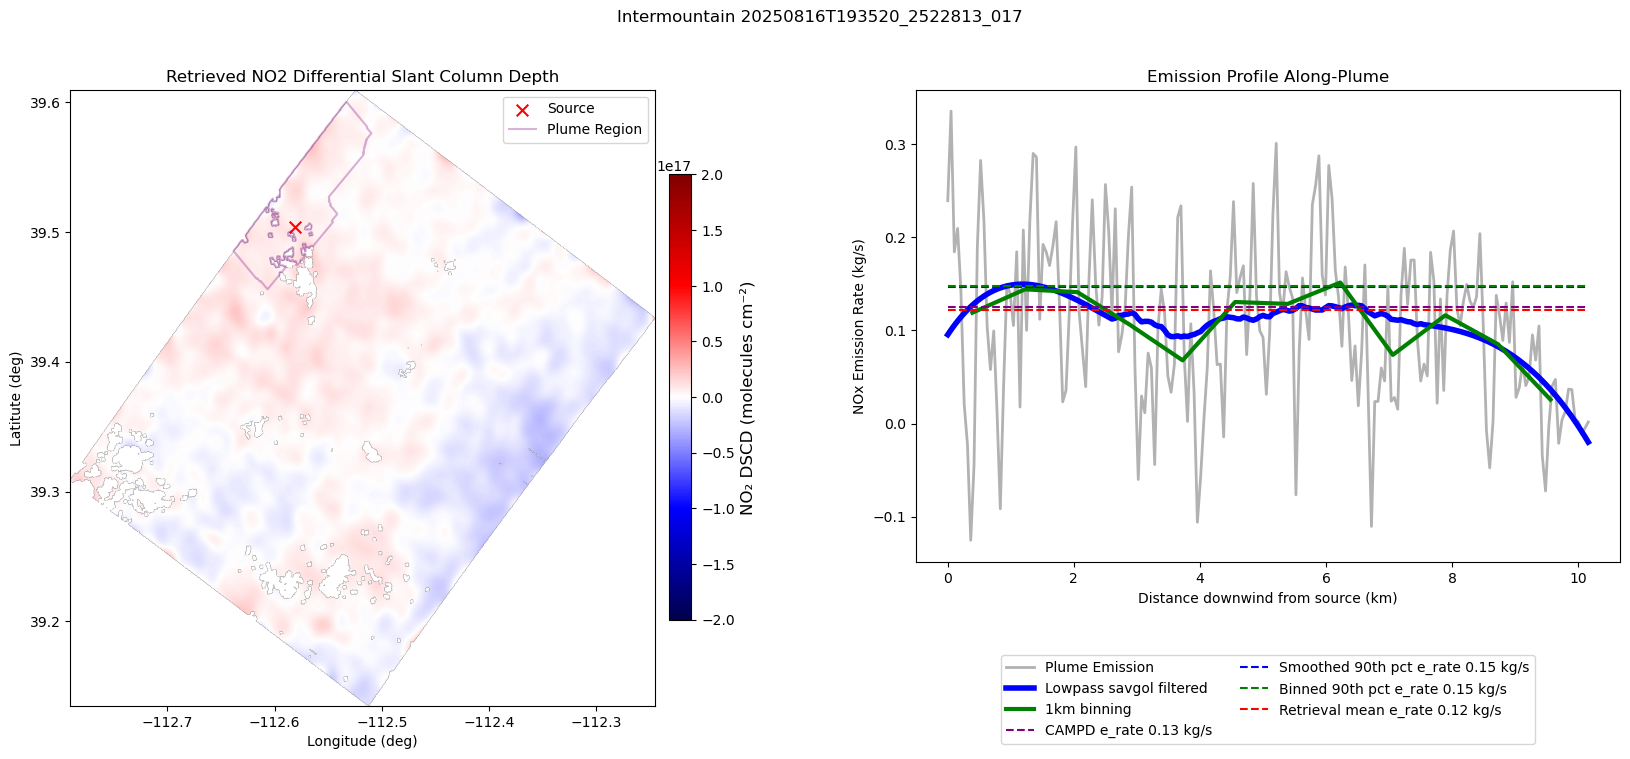

In [162]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,8))

plot_img = tv*1e19
# plot_img = dSCD_nan

im = ax[0].imshow(plot_img, cmap='seismic', origin='upper', 
              aspect='auto', vmin=-2e17, vmax=2e17, extent=bounds)
# cb = fig.colorbar(im, ax=ax[0])

cb = fig.colorbar(im, ax=ax[0], shrink=0.85, pad=0.02)
cb.set_label("NO₂ DSCD (molecules cm⁻²)", fontsize=12)
# shrink height and move it down slightly
cb.ax.set_position([
    cb.ax.get_position().x0,          # same left
    cb.ax.get_position().y0 + 0.05,   # move down a bit
    cb.ax.get_position().width,       # same width
    cb.ax.get_position().height * 0.85  # shrink height (0.85 = 85%)
])
ax[0].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red', s=70, label='Source')
ax[0].contour(~np.isnan(dSCD_plume_masked[:,:]), levels=[0.5], 
            colors='purple', alpha=0.3, linestyle='-', linewidths=1.5,
            extent=[bounds[0], bounds[1], bounds[3], bounds[2]])
ax[0].plot([], color='purple', alpha=0.3, label='Plume Region')
ax[0].legend()
ax[0].set_title("Retrieved NO2 Differential Slant Column Depth")
ax[0].set_xlabel("Longitude (deg)")
ax[0].set_ylabel("Latitute (deg)")

ax[0].set_xlim(lonmin_bnd, lonmax_bnd)
ax[0].set_ylim(latmin_bnd, latmax_bnd)

ax[1].plot(np.array(plume_extent)/1000, Q, 'k', lw=2, label='Plume Emission', alpha=0.3)
ax[1].plot(np.array(plume_extent)/1000, smoothed,'blue', lw=4, label='Lowpass savgol filtered')
ax[1].plot(np.array(bin_extent)/1000, binned, 'green', lw=3, label='1km binning')

ax[1].hlines([campd_e_rate], xmin=0, xmax=np.max(plume_extent)/1000, color='purple', linestyle='--', 
           label=f'CAMPD e_rate {campd_e_rate:0.2f} kg/s')
ax[1].hlines([smoothed_maxrate], xmin=0, xmax=np.max(plume_extent)/1000, color='blue', linestyle='--', 
           label=f'Smoothed 90th pct e_rate {smoothed_maxrate:0.2f} kg/s')
ax[1].hlines([bin_maxrate], xmin=0, xmax=np.max(plume_extent)/1000, color='green', linestyle='--', 
           label=f'Binned 90th pct e_rate {bin_maxrate:0.2f} kg/s')
plt.hlines([e_rate], xmin=0, xmax=np.max(plume_extent)/1000, color='red', linestyle='--', 
           label=f'Retrieval mean e_rate {e_rate:0.2f} kg/s')
# ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


# shrink just this subplot height to make room
pos = ax[1].get_position()
ax[1].set_position([pos.x0, pos.y0 + 0.18, pos.width, pos.height - 0.18])

# legend under plot
ax[1].legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.40),
    ncol=2
)

ax[1].set_ylabel("NOx Emission Rate (kg/s)")
ax[1].set_xlabel("Distance downwind from source (km)")
ax[1].set_title("Emission Profile Along-Plume")

# y = np.array([0.74, 0.645, 0.12]).T
# x = np.array([0.59, 0.72, 0.11]).T

y = np.array([0.215, 0.245, 0.115,])#0.37])
x = np.array([0.18,  0.22,  0.14,])#  0.19])


# --- scatter ---
# ax[2].scatter(x, y, label="Retrievals")

# --- best fit line ---
coef = np.polyfit(x, y, 1)     # slope, intercept
m, b = coef
y_pred = m * x + b

# R^2
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

# line for plotting
x_line = np.linspace(0, 0.4, 100)
y_line = m * x_line + b

label = f"y = {m:.3f}x + {b:.3f}\n$R^2$ = {r2:.3f}"
plt.suptitle(f"{loc_name} {granule_name}")

In [163]:
retrieval_log_fn = f'retr_{loc_name}.csv'
datalog_cols = ['GRANULE', 'CAMPD', 'SMOOTHED', 'BINNED', 'MEAN']
if os.path.exists(retrieval_log_fn):
    retr_log = pd.read_csv(retrieval_log_fn)
    
else:
    retr_log = pd.DataFrame(columns=datalog_cols)

if granule_name not in retr_log['GRANULE'].values:
    g_dat = {
        'GRANULE': granule_name,
        'CAMPD': campd_e_rate,
        'SMOOTHED': smoothed_maxrate,
        'BINNED': bin_maxrate,
        'MEAN': e_rate
    }
    retr_log = pd.concat([retr_log, pd.DataFrame(g_dat, index=[0])])
    retr_log.to_csv(retrieval_log_fn, index=False)

In [181]:
data_for_loc

,LOC_NAME,GRANULE,LON,LAT,GOOD_DATA,PLUME,CAMPD_RATE,HRRR_AGL_DIR,HRRR_AGL_SPD,HRRR_10M_DIR,HRRR_10M_SPD,GEOSFP_50M_DIR,GEOSFP_50M_SPD
227,Intermountain,20240402T192354_2409313_017,-112.5811,39.5035,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
228,Intermountain,20231001T201146_2327413_013,-112.5811,39.5035,True,False,0.132742,220.708236,8.556138,231.269623,6.499467,218.571014,8.709607
229,Intermountain,20231005T183601_2327812_013,-112.5811,39.5035,True,True,0.143605,25.604810,2.980168,354.100351,2.581978,16.761661,2.776960
230,Intermountain,20230601T202821_2315214_013,-112.5811,39.5035,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
231,Intermountain,20250613T205135_2516413_017,-112.5811,39.5035,True,False,0.081262,229.010431,7.665161,247.644344,6.225366,211.424782,5.935522
232,Intermountain,20230405T190521_2309513_013,-112.5811,39.5035,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233,Intermountain,20240804T181803_2421712_014,-112.5811,39.5035,True,True,0.182110,224.778829,3.388981,221.150580,2.949279,252.962293,3.087215
234,Intermountain,20240406T174711_2409712_013,-112.5811,39.5035,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235,Intermountain,20250728T202621_2520913_013,-112.5811,39.5035,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
236,Intermountain,20250609T222850_2516014_017,-112.5811,39.5035,True,True,0.094091,336.687827,2.366624,353.233654,1.415626,287.243721,5.647993


In [164]:
import pandas as pd
import numpy as np

# plume-only per-loc table (has winds + CAMPD_RATE, etc.)
df_loc = data_for_loc.loc[data_for_loc["PLUME"] == True].copy()

# retrieval log table (has GRANULE + retrieval outputs you want on y-axis)
retr_log = pd.read_csv(retrieval_log_fn).copy()

# If retr_log has no LOC_NAME column, this merge is still fine for a single location,
# but if you ever concatenate multiple locations, add LOC_NAME to retr_log (recommended).
plot_df = df_loc.merge(
    retr_log,
    on="GRANULE",
    how="inner",
    validate="one_to_one"  # change to "many_to_one" if retr_log has unique GRANULE but df_loc doesn't
)

# # Optional: check what didn't match (debug)
# missing_in_retr = set(df_loc["GRANULE"]) - set(retr_log["GRANULE"])
# missing_in_loc  = set(retr_log["GRANULE"]) - set(df_loc["GRANULE"])
# print("Unmatched (in plume df but not retr_log):", len(missing_in_retr))
# print("Unmatched (in retr_log but not plume df):", len(missing_in_loc))
plot_df

,LOC_NAME,GRANULE,LON,LAT,GOOD_DATA,PLUME,CAMPD_RATE,HRRR_AGL_DIR,HRRR_AGL_SPD,HRRR_10M_DIR,HRRR_10M_SPD,GEOSFP_50M_DIR,GEOSFP_50M_SPD,CAMPD,SMOOTHED,BINNED,MEAN
0,Intermountain,20231005T183601_2327812_013,-112.5811,39.5035,True,True,0.143605,25.604810,2.980168,354.100351,2.581978,16.761661,2.776960,0.143605,0.206370,0.217798,0.113187
1,Intermountain,20240804T181803_2421712_014,-112.5811,39.5035,True,True,0.182110,224.778829,3.388981,221.150580,2.949279,252.962293,3.087215,0.182110,0.242330,0.254245,0.146221
2,Intermountain,20250609T222850_2516014_017,-112.5811,39.5035,True,True,0.094091,336.687827,2.366624,353.233654,1.415626,287.243721,5.647993,0.094091,0.089047,0.113763,0.076829
3,Intermountain,20250816T193520_2522813_017,-112.5811,39.5035,True,True,0.125494,207.727962,8.012010,204.215610,6.899699,210.358856,6.728566,0.125494,0.147145,0.147887,0.121965
4,Intermountain,20241005T174121_2427912_013,-112.5811,39.5035,True,True,0.190563,349.953482,2.191188,289.290145,0.364025,297.957291,3.640325,0.190563,0.152829,0.170666,0.127772
5,Intermountain,20240212T214534_2404314_009,-112.5811,39.5035,True,True,0.084655,131.469158,0.925973,142.775892,0.924072,350.295682,0.275688,0.084655,0.018751,0.017871,0.018153
6,Intermountain,20241001T191716_2427513_010,-112.5811,39.5035,True,True,0.219389,304.213422,0.597269,284.847680,0.865976,278.538435,1.952249,0.219389,0.181135,0.183334,0.116323
7,Intermountain,20240216T200912_2404713_005,-112.5811,39.5035,True,True,0.075906,210.819277,2.344696,219.039332,1.792785,277.195290,3.062381,0.075906,0.091755,0.108980,0.082537
8,Intermountain,20230927T214729_2327014_012,-112.5811,39.5035,True,True,0.160136,221.033073,6.204433,235.850876,5.364368,219.760897,6.131271,0.160136,0.164904,0.198860,0.161802
9,Intermountain,20230202T193710_2303313_007,-112.5811,39.5035,True,True,0.186295,238.670961,0.500378,247.134267,1.281846,70.485196,1.059265,0.186295,0.014150,0.014488,0.011126


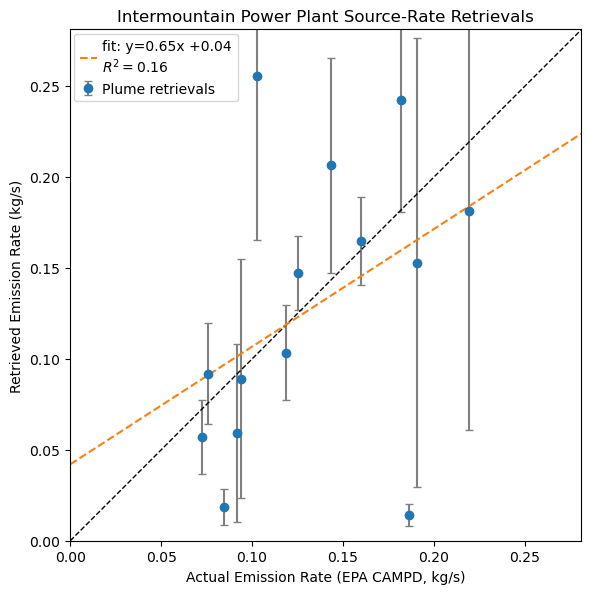

In [180]:
import numpy as np
import matplotlib.pyplot as plt

# Truth (x)
x = plot_df["CAMPD_RATE"].to_numpy(dtype=float)

# Retrieved variants (per-granule)
retr_cols = ["SMOOTHED", "BINNED", "MEAN"]
R = plot_df[retr_cols].to_numpy(dtype=float)  # shape (N, 3)

# Choose what you plot as the central retrieved value:
# Option A (common): plot MEAN
y = plot_df["SMOOTHED"].to_numpy(dtype=float)

# Option B: plot average of the 3 (often nice if you’re treating them as an ensemble)
# y = np.nanmean(R, axis=1)

# Processing / retrieval spread (additive)
sigma_proc = np.nanstd(R, axis=1, ddof=1)  # per-granule

# Wind variants (per-granule)
wind_cols = ["HRRR_AGL_SPD", "HRRR_10M_SPD", "GEOSFP_50M_SPD"]
W = plot_df[wind_cols].to_numpy(dtype=float)

U = np.nanmean(W, axis=1)
sigma_U = np.nanstd(W, axis=1, ddof=1)

# Total y-uncertainty: sqrt( proc^2 + (E * sigma_U/U)^2 )
sigma_y = np.full_like(y, np.nan, dtype=float)

ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma_proc) & np.isfinite(U) & np.isfinite(sigma_U) & (U > 0)
sigma_y[ok] = np.sqrt(
    sigma_proc[ok]**2 +
    (y[ok] * (sigma_U[ok] / U[ok]))**2
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(
    x[ok], y[ok],
    yerr=sigma_y[ok],
    fmt='o',
    capsize=3,
    elinewidth=1.5,
    ecolor='0.5',
    label="Plume retrievals"
)

# 1:1 line
lims = [0, max(np.nanmax(x[ok]), np.nanmax(y[ok])) * 1.1]
ax.plot(lims, lims, 'k--', lw=1, )

# Fit + R^2
m, b = np.polyfit(x[ok], y[ok], 1)
xx = np.linspace(lims[0], lims[1], 200)
r2 = np.corrcoef(x[ok], y[ok])[0, 1]**2

ax.plot(xx, m*xx + b, '--', lw=1.5, label=f"fit: y={m:.2f}x {b:+.2f}\n$R^2={r2:.2f}$")
ax.set_xlabel("Actual Emission Rate (EPA CAMPD, kg/s)")
ax.set_ylabel("Retrieved Emission Rate (kg/s)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.legend(
    frameon=True,
    fontsize=10,          # default ~12
    handlelength=1.2,
    handletextpad=0.4,
    borderaxespad=0.3
)
plt.tight_layout()
plt.title('Intermountain Power Plant Source-Rate Retrievals')
plt.show()

